In [1]:
# --- 1. SETUP E CONFIGURAZIONE (CORRETTO PER GOOGLE COLAB) ---
import os
import sys
import json
import glob
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import tensorflow as tf
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

# --- MODIFICHE PER COLAB ---

# 1. Monta Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True) # Aggiungo force_remount per sicurezza

# 2. Definisci il percorso radice del tuo progetto su Google Drive
PROJECT_ROOT = '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab'

# 3. Aggiungi la cartella del progetto (che contiene 'src') al path di Python
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Ora puoi importare i tuoi moduli
from src import data_loader, models, evaluation

# --- FINE MODIFICHE PER COLAB ---

# --- Configurazione specifica della pipeline AVANZATA ---
PIPELINE_NAME = "Pipeline_B_Advanced_3GRU_Balanced"
# === USA LA NUOVA FUNZIONE DI CARICAMENTO ===
FEATURE_LOADER_FN = data_loader.load_precomputed_mfcc_stack
# === USA IL NUOVO CREATORE DI MODELLI ===
MODEL_CREATOR_FN = models.create_advanced_2d_cnn_3gru_model

MODEL_FILENAME = "model_B_advanced.keras"
METADATA_FILENAME = "model_B_advanced_metadata.json"

# === CORREZIONE DEFINITIVA DI TUTTI I PERCORSI ===
# Usa os.path.join con PROJECT_ROOT per creare percorsi assoluti e robusti
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data/processed/features_v2")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
CSV_PATH = os.path.join(PROJECT_ROOT, "data/raw/UrbanSound8K.csv")
# ================================================

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"--- ESECUZIONE: {PIPELINE_NAME} ---")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Features Directory: {FEATURES_DIR}") # Ora stamperà il percorso completo
print(f"Models Directory: {MODELS_DIR}")
print(f"CSV File Path: {CSV_PATH}")

# --- 2. CARICAMENTO DATI ---
print("\n[Fase 1/5] Caricamento di tutti i dati...")
all_data = {}
# Questa riga ora funzionerà perché FEATURES_DIR è corretto
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))

# Aggiungiamo un controllo per essere sicuri
if not fold_dirs:
    raise FileNotFoundError(f"Nessuna cartella 'fold*' trovata in {FEATURES_DIR}. Controlla che il percorso sia corretto e che le cartelle esistano.")

for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    print(f"Caricando {fold_name}...")
    X_fold, y_fold = data_loader.collect_fold_data(
        fold_dir, FEATURE_LOADER_FN
    )
    all_data[fold_name] = (X_fold, y_fold)
print("Caricamento completato.")



[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2412492737573652581
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 9893572733646961135
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]
Mounted at /content/drive
--- ESECUZIONE: Pipeline_B_Advanced_3GRU_Balanced ---
Project Root: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab
Features Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/processed/features_v2
Models Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models
CSV File Path: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/raw/UrbanSound8K.csv

[Fase 1/5] Caricamento di tutti i dati...
Caricando fold1...
Caricando fold10...
Caricando fold2...
Caricando fold3...
Caricando fold4...
Caricando f

In [ ]:
# --- 3. CROSS-VALIDATION ---
print("\n[Fase 2/5] Avvio Cross-Validation per il modello avanzato...")
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)
# Prende la shape del primo campione del primo fold caricato
input_shape = list(all_data.values())[0][0][0].shape

fold_accuracies = []
all_y_true_cv, all_y_pred_cv = [], []

# Itera su ogni fold, usandolo una volta come set di validazione
for i, val_fold_name in enumerate(sorted(all_data.keys())): # Aggiunto sorted per consistenza
    print(f"\n--- CV Fold {i+1}/{len(all_data)} (Validation: {val_fold_name}) ---")

    # --- Preparazione dati train/val per questo fold ---
    # Set di validazione
    X_val, y_val = all_data[val_fold_name]

    # Set di training (tutti gli altri fold)
    train_folds_data = [data for name, data in all_data.items() if name != val_fold_name]
    # np.vstack e np.concatenate sono efficienti per unire i dati dei fold
    X_train = np.vstack([f[0] for f in train_folds_data])
    y_train = np.concatenate([f[1] for f in train_folds_data])

    # === MODIFICA CHIAVE PER FOCAL LOSS ===
    # Converti le etichette di training e validazione in formato one-hot
    y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
    y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)
    # ======================================

    # Creazione del modello avanzato
    # La funzione MODEL_CREATOR_FN è già impostata all'inizio del notebook
    model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)

    # Calcolo dei pesi per il set di training di questo specifico fold
    # (Opzionale con Focal Loss, ma può ancora aiutare)
    class_weights_cv = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict_cv = dict(enumerate(class_weights_cv))

    # Addestramento del modello per questo fold
    history = model.fit(
        X_train, y_train_one_hot,           # Usa etichette one-hot
        validation_data=(X_val, y_val_one_hot), # Usa etichette one-hot
        epochs=50,  # 50 epoche sono un buon compromesso per la CV
        batch_size=32,
        # class_weight=class_weight_dict_cv, # Puoi decidere se usarlo insieme a Focal Loss
        callbacks=[
            # EarlyStopping è quasi obbligatorio nella CV per risparmiare tempo
            # e ottenere il miglior modello per ogni fold.
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
        ],
        verbose=0  # Mettiamo a 0 per non inondare l'output durante la CV
    )

    # Valutazione sul fold di validazione
    loss, acc = model.evaluate(X_val, y_val_one_hot, verbose=0) # Usa etichette one-hot
    fold_accuracies.append(acc)

    # Predizioni per la matrice di confusione aggregata
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1) # Ottieni gli indici delle classi

    all_y_true_cv.extend(y_val) # Aggiungi le etichette originali (interi)
    all_y_pred_cv.extend(y_pred_labels) # Aggiungi le etichette predette (interi)

    print(f"Accuracy del fold: {acc:.4f}")

# Calcolo delle performance medie
mean_acc_cv = np.mean(fold_accuracies)
std_acc_cv = np.std(fold_accuracies)
print(f"\nRisultato Cross-Validation:")
print(f"  - Accuracy media: {mean_acc_cv:.4f} ± {std_acc_cv:.4f}")


[Fase 2/5] Avvio Cross-Validation...

--- CV Fold 1/10 (Validation: fold1) ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy del fold: 0.6695

--- CV Fold 2/10 (Validation: fold10) ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy del fold: 0.7419

--- CV Fold 3/10 (Validation: fold2) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy del fold: 0.6677

--- CV Fold 4/10 (Validation: fold3) ---
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy del fold: 0.6363

--- CV Fold 5/10 (Validation: fold4) ---
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy del fold: 0.7289

--- CV Fold 6/10 (Validation: fold5) ---
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy del fold: 0.7256

--- CV Fold 7/10 (Validation: fold6) ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy del fold: 0.7219

--- CV Fold 8/10 (Validation: fold7) ---
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy del fold: 0.7497

--- CV Fold 9/10 (Validation: fold8) ---
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy del fol

In [2]:
# --- 4. ADDESTRAMENTO MODELLO FINALE (CORRETTO) ---
print("\n[Fase 3/5] Addestramento del modello finale su split 80/20...")

# 1. Creazione dello split con i nomi di variabile "_final"
X_train_final, y_train_final, X_test_final, y_test_final = data_loader.get_train_test_split_from_folds(
    all_data,
    meta_file_path=CSV_PATH,
    test_size=0.2
)

# 2. Definizione dei parametri usando le variabili corrette
#    Usa X_train_final, non X_train
input_shape = X_train_final[0].shape
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)

# 3. Conversione a one-hot usando le variabili corrette
#    Usa y_train_final e y_test_final
y_train_one_hot = tf.keras.utils.to_categorical(y_train_final, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_final, num_classes=num_classes)

# 4. Creazione del modello
final_model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)
final_model.summary()

# 5. Addestramento del modello usando le variabili corrette
#    Usa X_train_final, y_train_one_hot, X_test_final, y_test_one_hot
final_history = final_model.fit(
    X_train_final, y_train_one_hot,
    validation_data=(X_test_final, y_test_one_hot),
    epochs=100,
    batch_size=32,
    callbacks=[
        # EarlyStopping è fortemente consigliato con modelli complessi
        #EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)


[Fase 3/5] Addestramento del modello finale su split 80/20...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 173, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 173, 64)    │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 173, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 86, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 86, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 21, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 21, 256)        │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,962 (4.26 MB)

 Trainable params: 1,117,322 (4.26 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.2727 - loss: 0.4005 - val_accuracy: 0.4205 - val_loss: 0.2985 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.5520 - loss: 0.2194 - val_accuracy: 0.4911 - val_loss: 0.3219 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6647 - loss: 0.1533 - val_accuracy: 0.6385 - val_loss: 0.2072 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7300 - loss: 0.1301 - val_accuracy: 0.6374 - val_loss: 0.2164 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7660 - loss: 0.1065 - val_accuracy: 0.6702 - val_loss: 0.1865 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7875 - loss: 0.0934 - val_accuracy: 0.6630 - val_loss: 0.2005 - learning_rate: 3.0000e-04
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 4


[Fase 4/5] Valutazione del modello finale...
Performance finale sul Test Set:
  - Loss: 0.0994
  - Accuracy: 0.8493

Generazione del report di classificazione e della matrice di confusione...
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

--- Report di Classificazione Dettagliato ---
                  precision    recall  f1-score   support

 air_conditioner       0.78      0.81      0.79       196
        car_horn       0.95      0.93      0.94       159
children_playing       0.82      0.80      0.81       182
        dog_bark       0.88      0.90      0.89       159
        drilling       0.70      0.67      0.69       169
   engine_idling       0.89      0.82      0.85       225
        gun_shot       0.97      0.96      0.97       237
      jackhammer       0.73      0.94      0.82       174
           siren       0.91      0.87      0.89       155
    street_music       0.87      0.75      0.80       142

        accuracy                           0.85      1798
       macro avg      

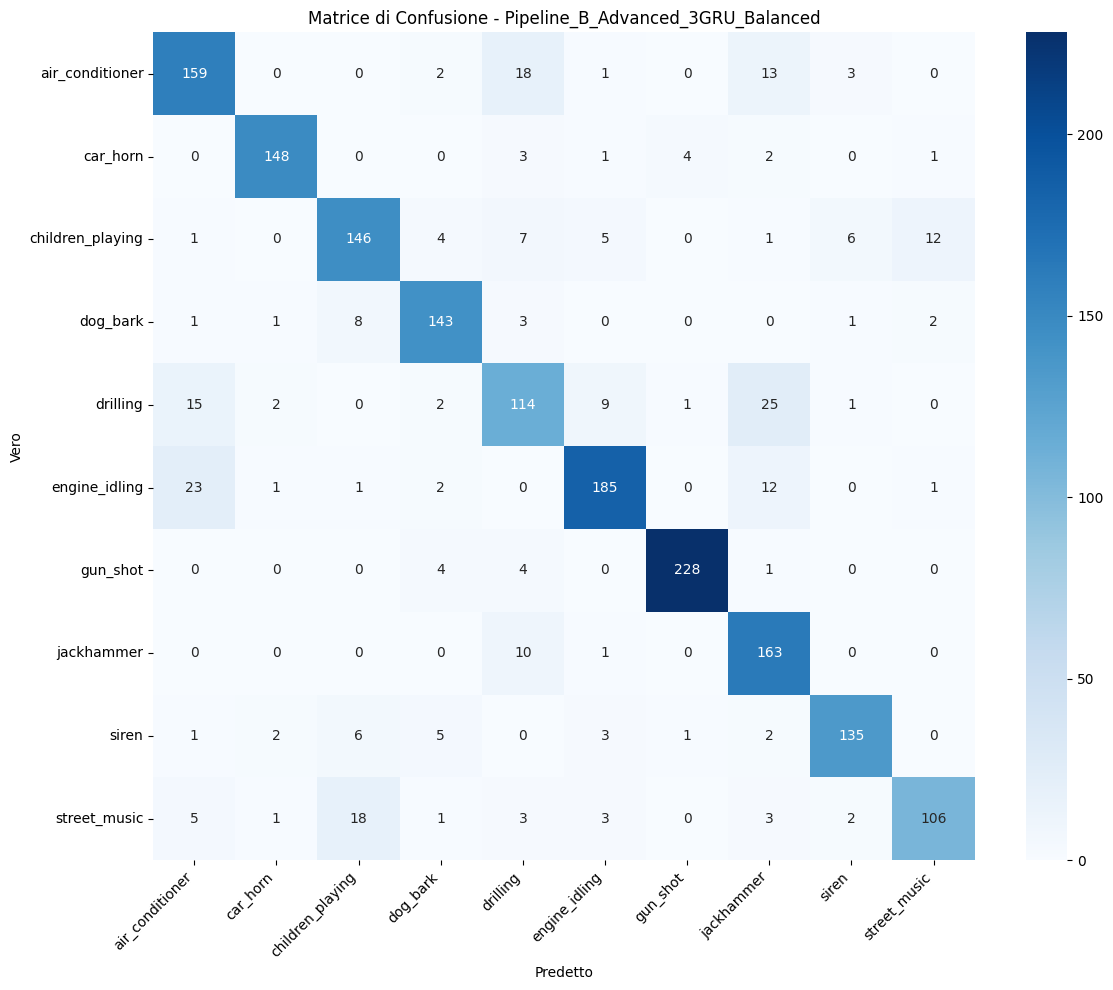


[Fase 5/5] Salvataggio del modello e dei metadati...
Modello salvato in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_B_advanced.keras
Metadati salvati in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_B_advanced_metadata.json


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# --- 5. VALUTAZIONE DETTAGLIATA E SALVATAGGIO ---

print("\n[Fase 4/5] Valutazione del modello finale...")

# 1. Valutazione di base (Loss e Accuracy)
#    Usa le etichette one-hot perché il modello è stato compilato con una loss
#    che le richiede (CategoricalFocalCrossentropy).
final_loss, final_accuracy = final_model.evaluate(X_test_final, y_test_one_hot, verbose=0)
print(f"Performance finale sul Test Set:")
print(f"  - Loss: {final_loss:.4f}")
print(f"  - Accuracy: {final_accuracy:.4f}\n")

# 2. Ottieni le predizioni per un report più dettagliato
print("Generazione del report di classificazione e della matrice di confusione...")
y_pred_probs = final_model.predict(X_test_final)
y_pred_final = np.argmax(y_pred_probs, axis=1) # Converte le probabilità in etichette intere

# 3. Stampa del Classification Report
#    Usa le etichette originali (interi, non one-hot) per il report
print("\n--- Report di Classificazione Dettagliato ---")
print(classification_report(y_test_final, y_pred_final, target_names=class_names))

# 4. Generazione e Visualizzazione della Matrice di Confusione
print("\n--- Matrice di Confusione ---")
conf_matrix = confusion_matrix(y_test_final, y_pred_final)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice di Confusione - {PIPELINE_NAME}')
plt.xlabel('Predetto')
plt.ylabel('Vero')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


print("\n[Fase 5/5] Salvataggio del modello e dei metadati...")

# 5. Salva il modello
model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)
final_model.save(model_path)
print(f"Modello salvato in: {model_path}")

# 6. Salva i metadati
#    Rimuovo le chiavi della CV perché non vengono eseguite in questo script finale.
#    Aggiungo il percorso della figura della matrice di confusione se vuoi salvarla.
metadata = {
    "pipeline_name": PIPELINE_NAME,
    "model_architecture": "Advanced 2D-CNN + 3xBiGRU",
    "model_filename": MODEL_FILENAME,
    "input_shape": input_shape,
    "num_classes": num_classes,
    "class_names": class_names,
    "final_test_performance": {
        "accuracy": final_accuracy,
        "loss": final_loss
    }
}
metadata_path = os.path.join(MODELS_DIR, METADATA_FILENAME)
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"Metadati salvati in: {metadata_path}")